# Dataset Exploration

In [1]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
import cv2
import numpy as np

ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "data" / "raw" / "surface-crack"


image_paths = {}
for dir_name in DATA_DIR.iterdir():
    image_paths[dir_name.name] = list(dir_name.glob("*.jpg"))

# 1. Class Distribution / Image Dimension Analysis

In [2]:
sizes = {}

for label, paths in image_paths.items():
    first_image = cv2.imread(str(paths[0]))
    
    print("Class:", label)
    print("Shape:", first_image.shape)
    print("# of images:", len(paths), end="\n\n")

    for path in paths:
        img = cv2.imread(str(path))
        if img is not None:
            sizes[img.shape] = sizes.get(img.shape, 0) + 1
print("sizes:", sizes)

    

Class: Positive
Shape: (227, 227, 3)
# of images: 20000

Class: Negative
Shape: (227, 227, 3)
# of images: 20000

sizes: {(227, 227, 3): 40000}


# 2. Random Sample Visualization

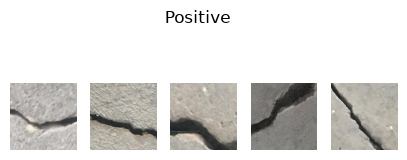

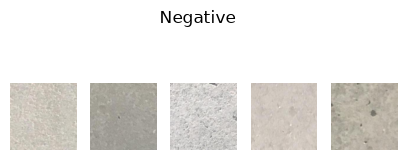

In [28]:
for label, paths in image_paths.items():
    rand_paths = random.sample(paths, 5)

    plt.figure(figsize=(5,5))

    for i, img_path in enumerate(rand_paths):
        image = cv2.imread(str(img_path))

        plt.subplot(3, 5, i+1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.axis("off")

    plt.suptitle(label)
    plt.show()


# 3. Pixel Value Analysis

## Objective
Understand pixel intensity distribution

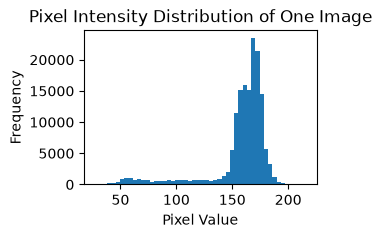

In [4]:
img_path = random.choice(image_paths['Positive'])
img = cv2.imread(str(img_path))
plt.figure(figsize=(3,2))
plt.hist(img.ravel(), bins=50)
plt.title("Pixel Intensity Distribution of One Image")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

## Hypothesis
Positive sample(defect) may have more darker pixels

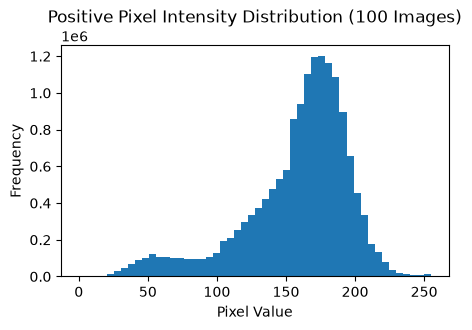

In [5]:
sample_paths = random.sample(image_paths['Positive'], 100)

image_list = []
for img_path in sample_paths:
    image = cv2.imread(str(img_path))
    image_list.append(image)
images = np.array(image_list)
plt.figure(figsize=(5,3))
plt.hist(images.ravel(), bins=50)
plt.title("Positive Pixel Intensity Distribution (100 Images)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

## Observation
Compared 100 random images from each class. Positive has more pixels around intensity 50.

## Interpretation
These low-intensity pixels may correspond to crack regions.

## Conclusion
Pixel intensity alone may provide useful information for distinguishing positive samples.

# 4. Average Image

Positive


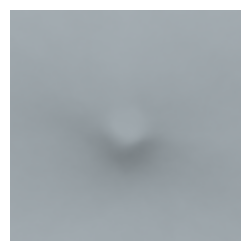

Negative


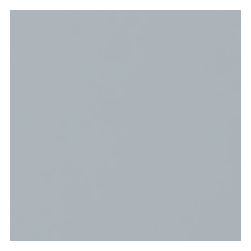

In [33]:
for label, paths in image_paths.items():
    print(label)

    img_list = []
    for path in random.sample(paths,2000):
        img = cv2.imread(str(path))
        img_list.append(img)
    images = np.array(img_list)
    mean_img = images.mean(axis=0).astype(np.uint8)
    plt.figure(figsize=(3,3))
    plt.imshow(mean_img)
    plt.axis("off")
    plt.show()

## Observation
Cracks appear to be roughly centered in many positive images.

## Interpretation
Dataset may have a center bias for crack locations.